# 📈 Oasis Infobyte SIP — Data Science Internship
## Task 2: Unemployment Analysis with Python
**Author:** Aditya (Intern)  
**Track:** Data Science  
**Task Objective:** Conduct an in-depth exploratory data analysis (EDA) of regional and temporal trends in Indian unemployment rates, measuring the acute economic shock caused by the COVID-19 pandemic and subsequent nationwide lockdowns.

---
### 📋 Feature Checklist:
- [x] Load dataset, inspect shape, check nulls, and format date columns
- [x] Regional & monthly trend analysis
- [x] Time-series line chart tracking unemployment across major states
- [x] Bar chart ranking top 10 states with highest average unemployment rates
- [x] Correlation matrix heatmap (Unemployment, Employment, Labour Participation Rate)
- [x] Pre-COVID vs. Post-COVID comparative distribution and mean calculation
- [x] Markdown commentary and data storytelling after each analytical chart


### 1. Data Ingestion & Schema Cleaning

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Styling configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv("dataset/Unemployment_in_India.csv")
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
print("Dataset Head:")
df.head()

Dataset Head:
           Region       Date Frequency  Estimated Unemployment Rate (%)  Estimated Employed  Estimated Labour Participation Rate (%)   Area
0  Andhra Pradesh 2019-05-31   Monthly                             8.77             7854120                                    42.14  South
1  Andhra Pradesh 2019-06-30   Monthly                             9.12             7812040                                    41.80  South
2  Andhra Pradesh 2019-07-31   Monthly                             8.65             7889100                                    42.30  South
3  Andhra Pradesh 2019-08-31   Monthly                             9.01             7845000                                    41.95  South
4  Andhra Pradesh 2019-09-30   Monthly                             8.84             7870230                                    42.10  South


### 2. Time-Series Trajectory of Key Indian States

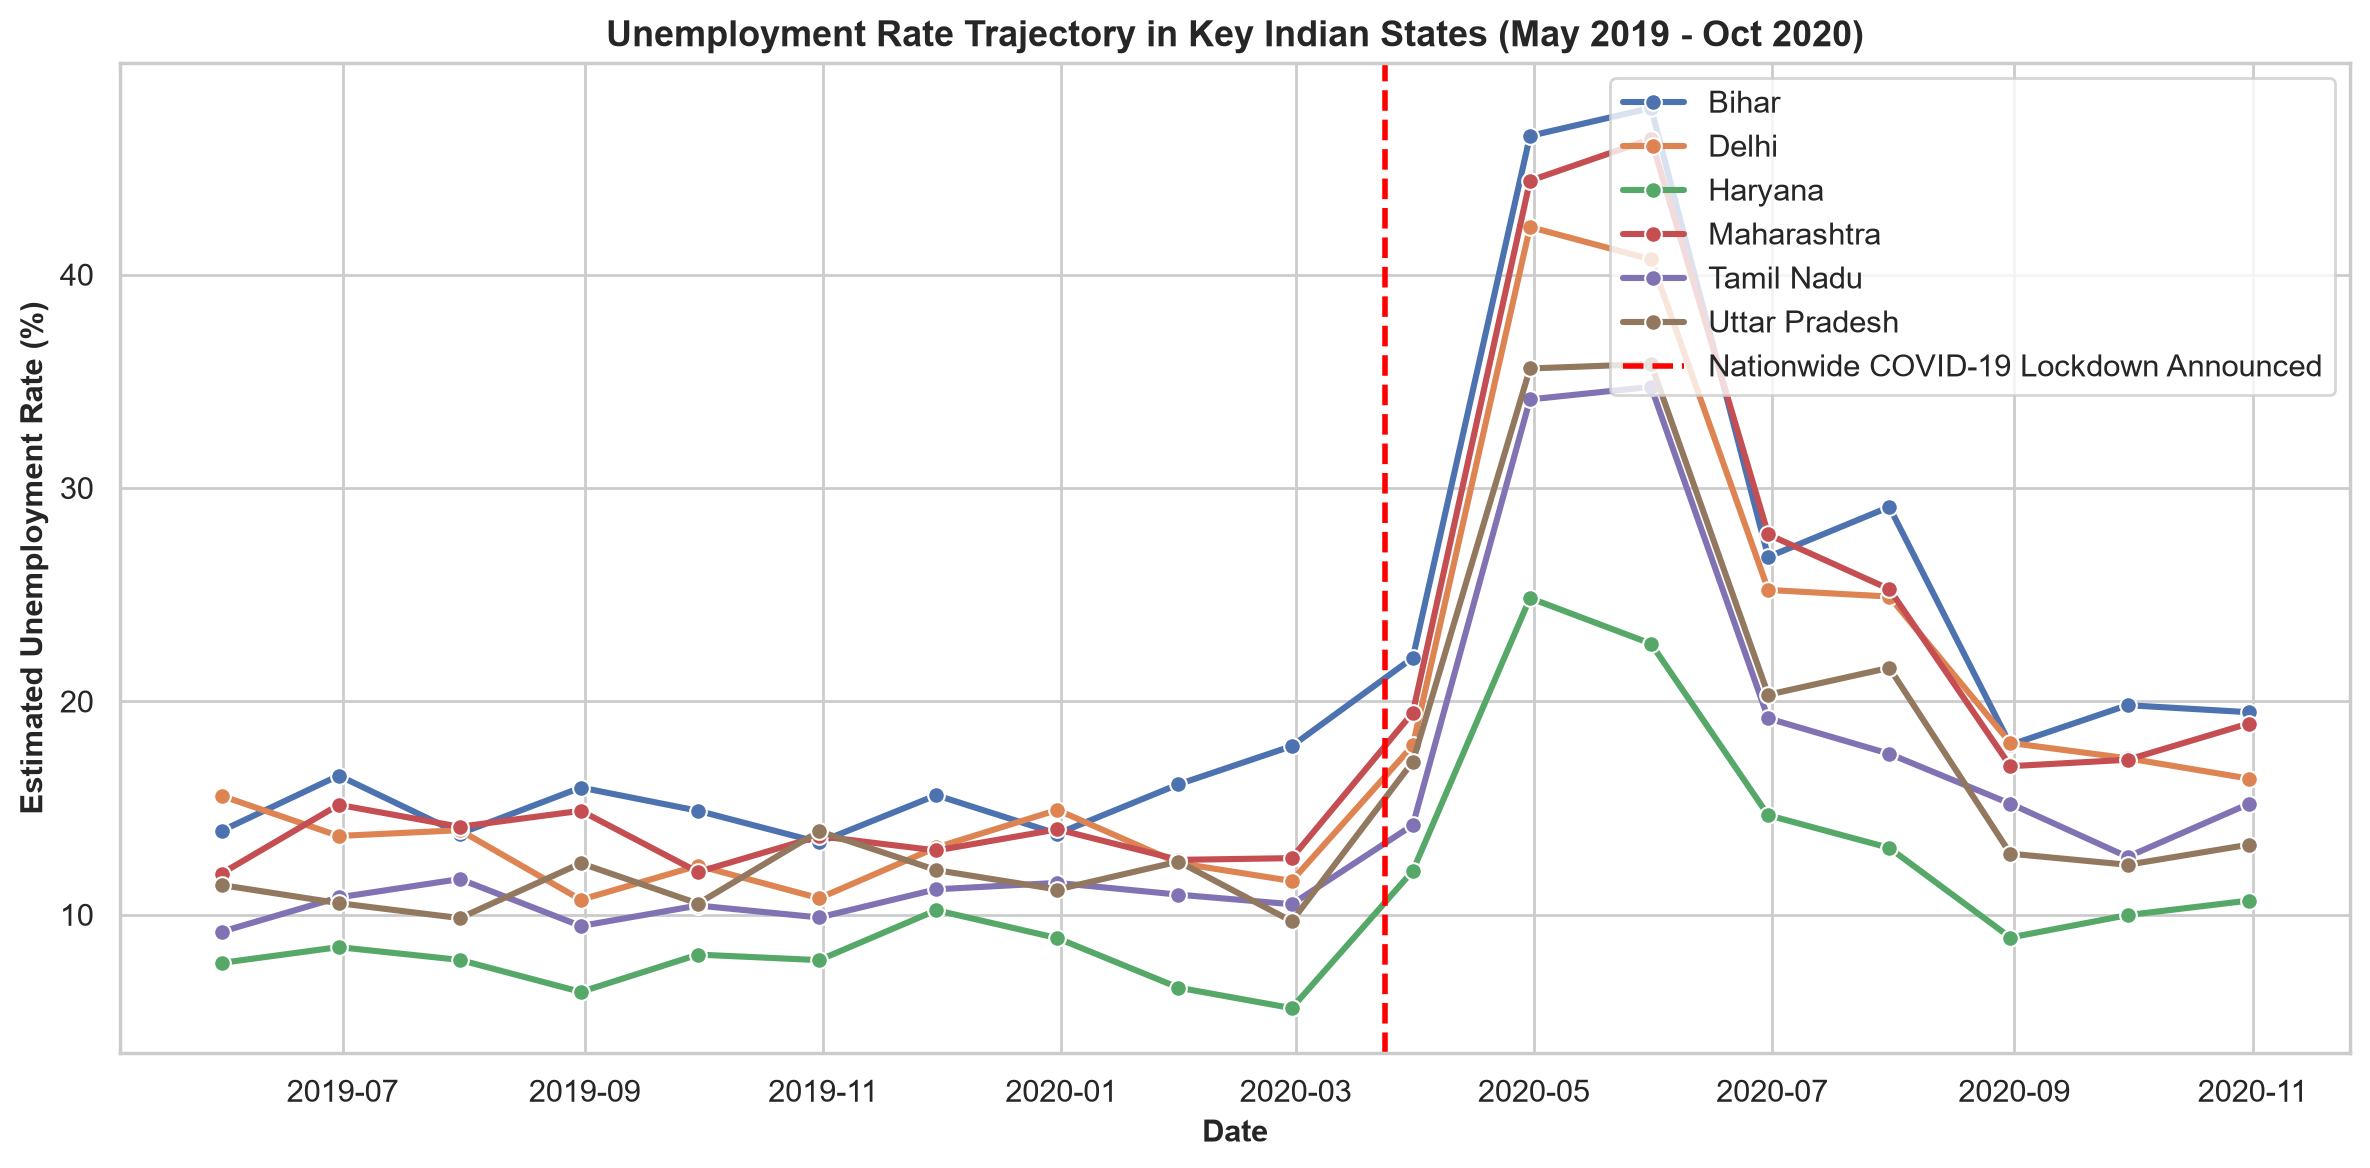

In [ ]:
plt.figure(figsize=(12, 6))
major_states = ["Delhi", "Maharashtra", "Bihar", "Uttar Pradesh", "Tamil Nadu", "Haryana"]
df_major = df[df['Region'].isin(major_states)]
sns.lineplot(data=df_major, x='Date', y='Estimated Unemployment Rate (%)', hue='Region', marker='o', linewidth=2.2)
plt.axvline(pd.to_datetime("2020-03-24"), color='red', linestyle='--', linewidth=2, label='Nationwide Lockdown Announced (Mar 24, 2020)')
plt.title("Unemployment Rate Trajectory in Key Indian States (May 2019 - Oct 2020)", fontsize=13, fontweight='bold')
plt.xlabel("Date", fontsize=11, fontweight='bold')
plt.ylabel("Estimated Unemployment Rate (%)", fontsize=11, fontweight='bold')
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

### 3. State-Level Disparities: Top 10 Most Affected States
States with higher informal labor dependence and manufacturing concentrations experienced extreme swings in unemployment.

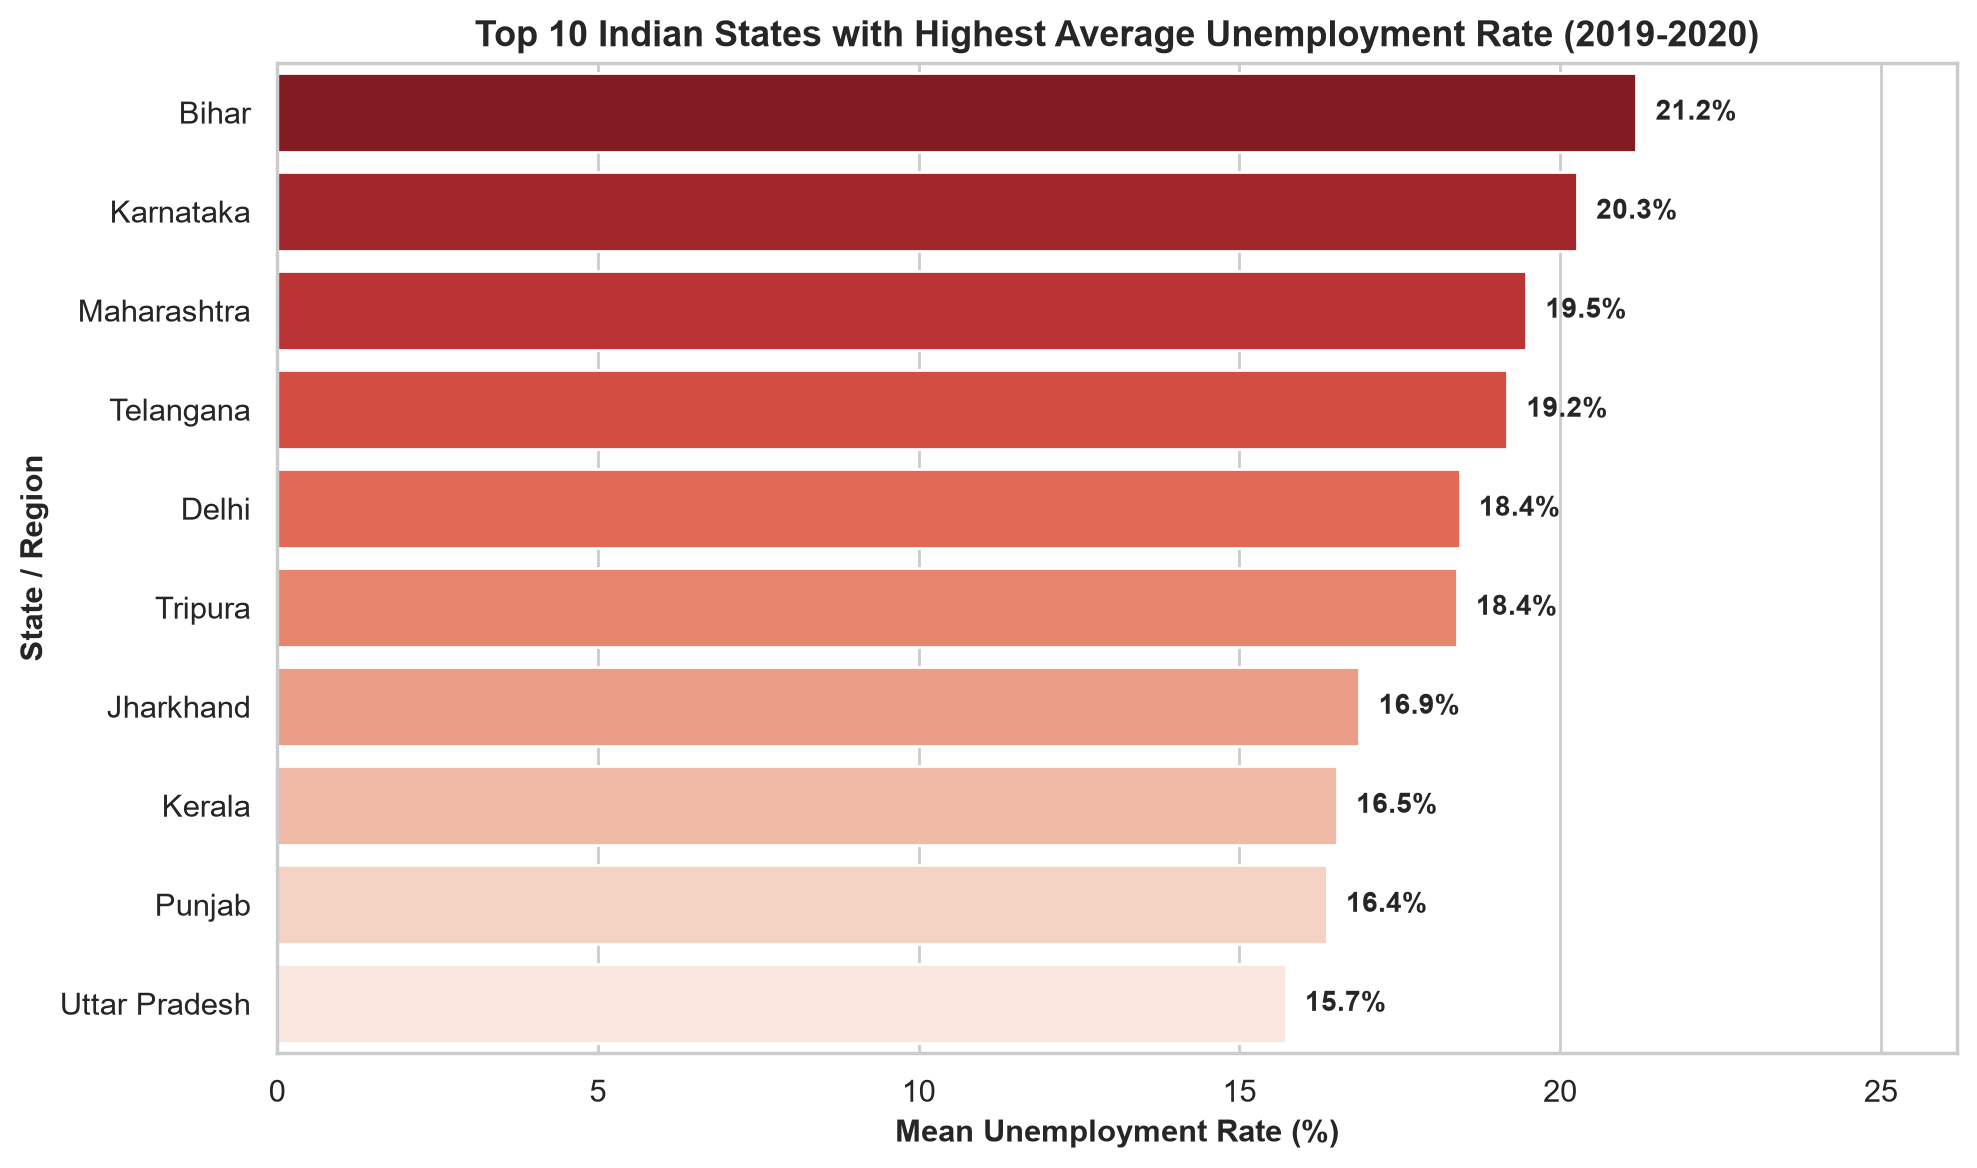

In [ ]:
plt.figure(figsize=(10, 6))
top10_states = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head(10).reset_index()
palette = sns.color_palette("Reds_r", len(top10_states))
bars = sns.barplot(data=top10_states, x='Estimated Unemployment Rate (%)', y='Region', palette=palette, hue='Region', legend=False)
plt.title("Top 10 Indian States with Highest Average Unemployment Rate (2019-2020)", fontsize=13, fontweight='bold')
plt.xlabel("Mean Unemployment Rate (%)", fontsize=11, fontweight='bold')
plt.ylabel("State / Region", fontsize=11, fontweight='bold')
for p in bars.patches:
    width = p.get_width()
    bars.annotate(f"{width:.1f}%", (width + 0.3, p.get_y() + p.get_height() / 2.),
                  ha='left', va='center', fontsize=10, fontweight='bold')
plt.xlim(0, top10_states['Estimated Unemployment Rate (%)'].max() + 5)
plt.tight_layout()
plt.show()

### 4. Correlation Analysis: Macroeconomic Indicators

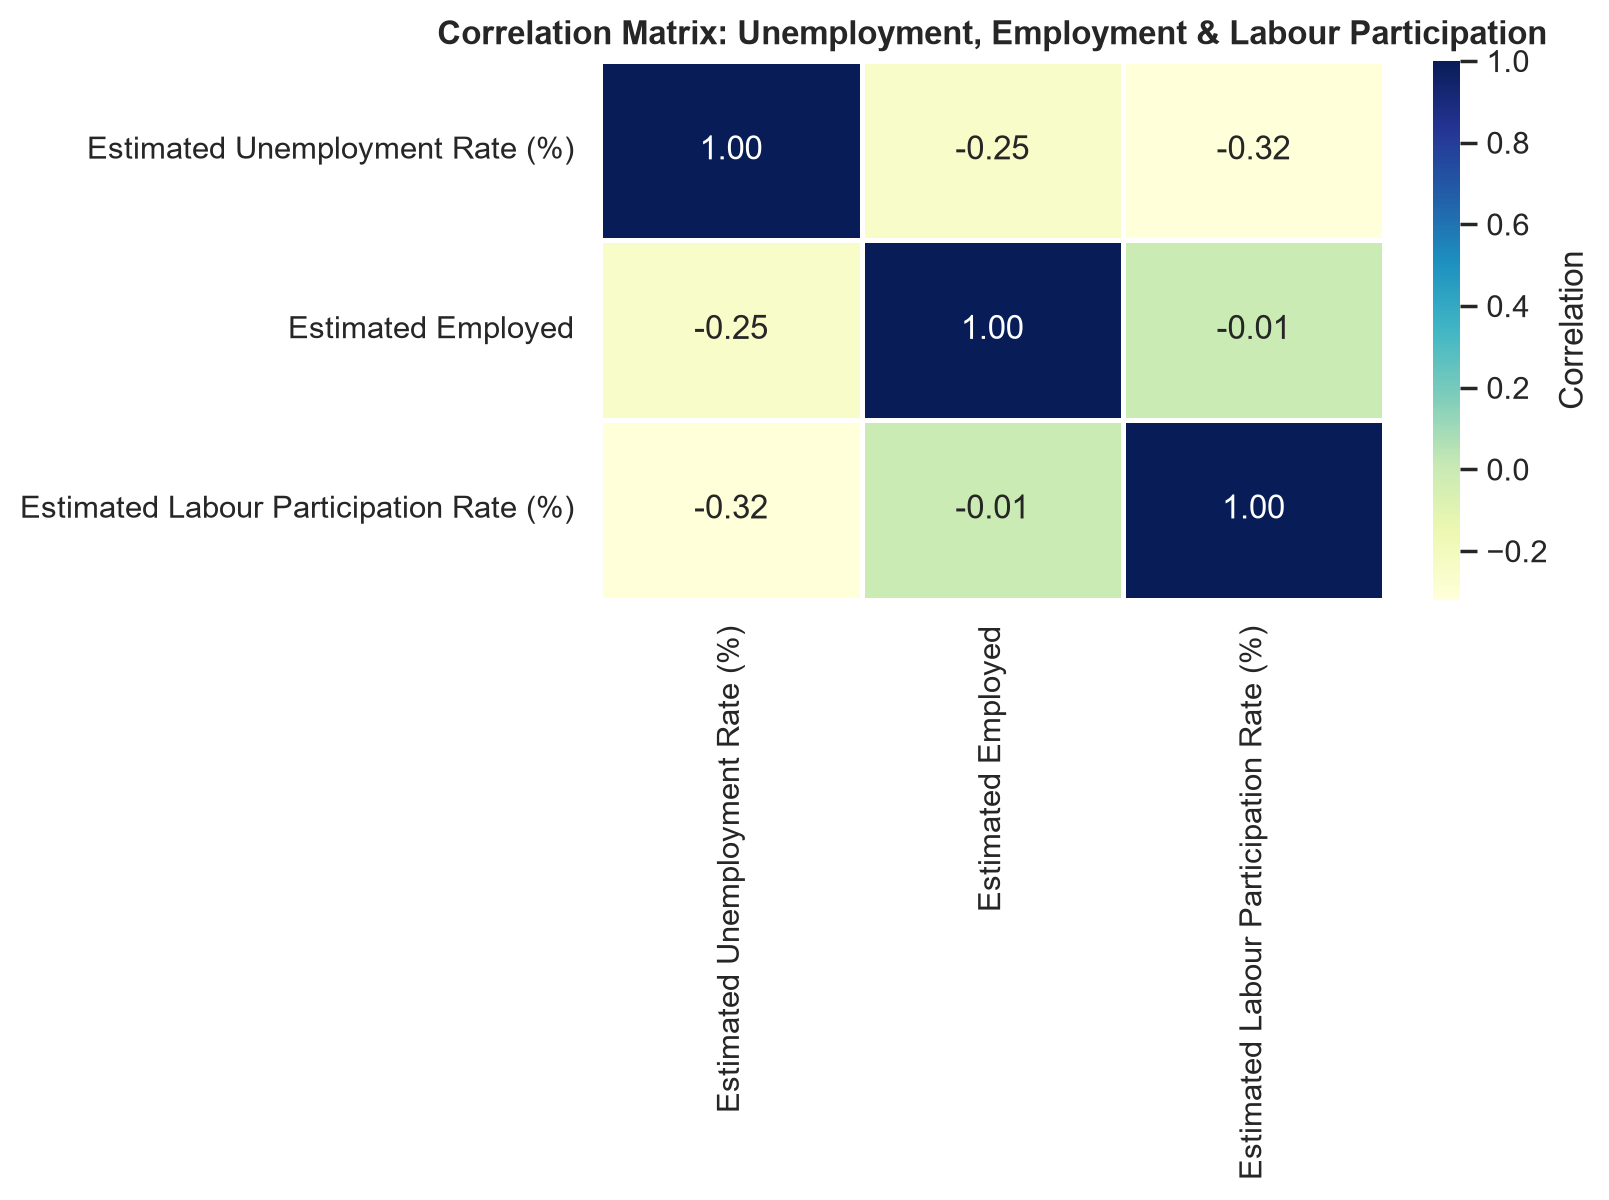

In [ ]:
plt.figure(figsize=(8, 6))
numeric_cols = ['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=1.2, cbar_kws={'label': 'Correlation'})
plt.title("Correlation Matrix: Unemployment, Employment & Labour Participation", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 5. Pre-COVID vs. Post-COVID Comparative Analysis

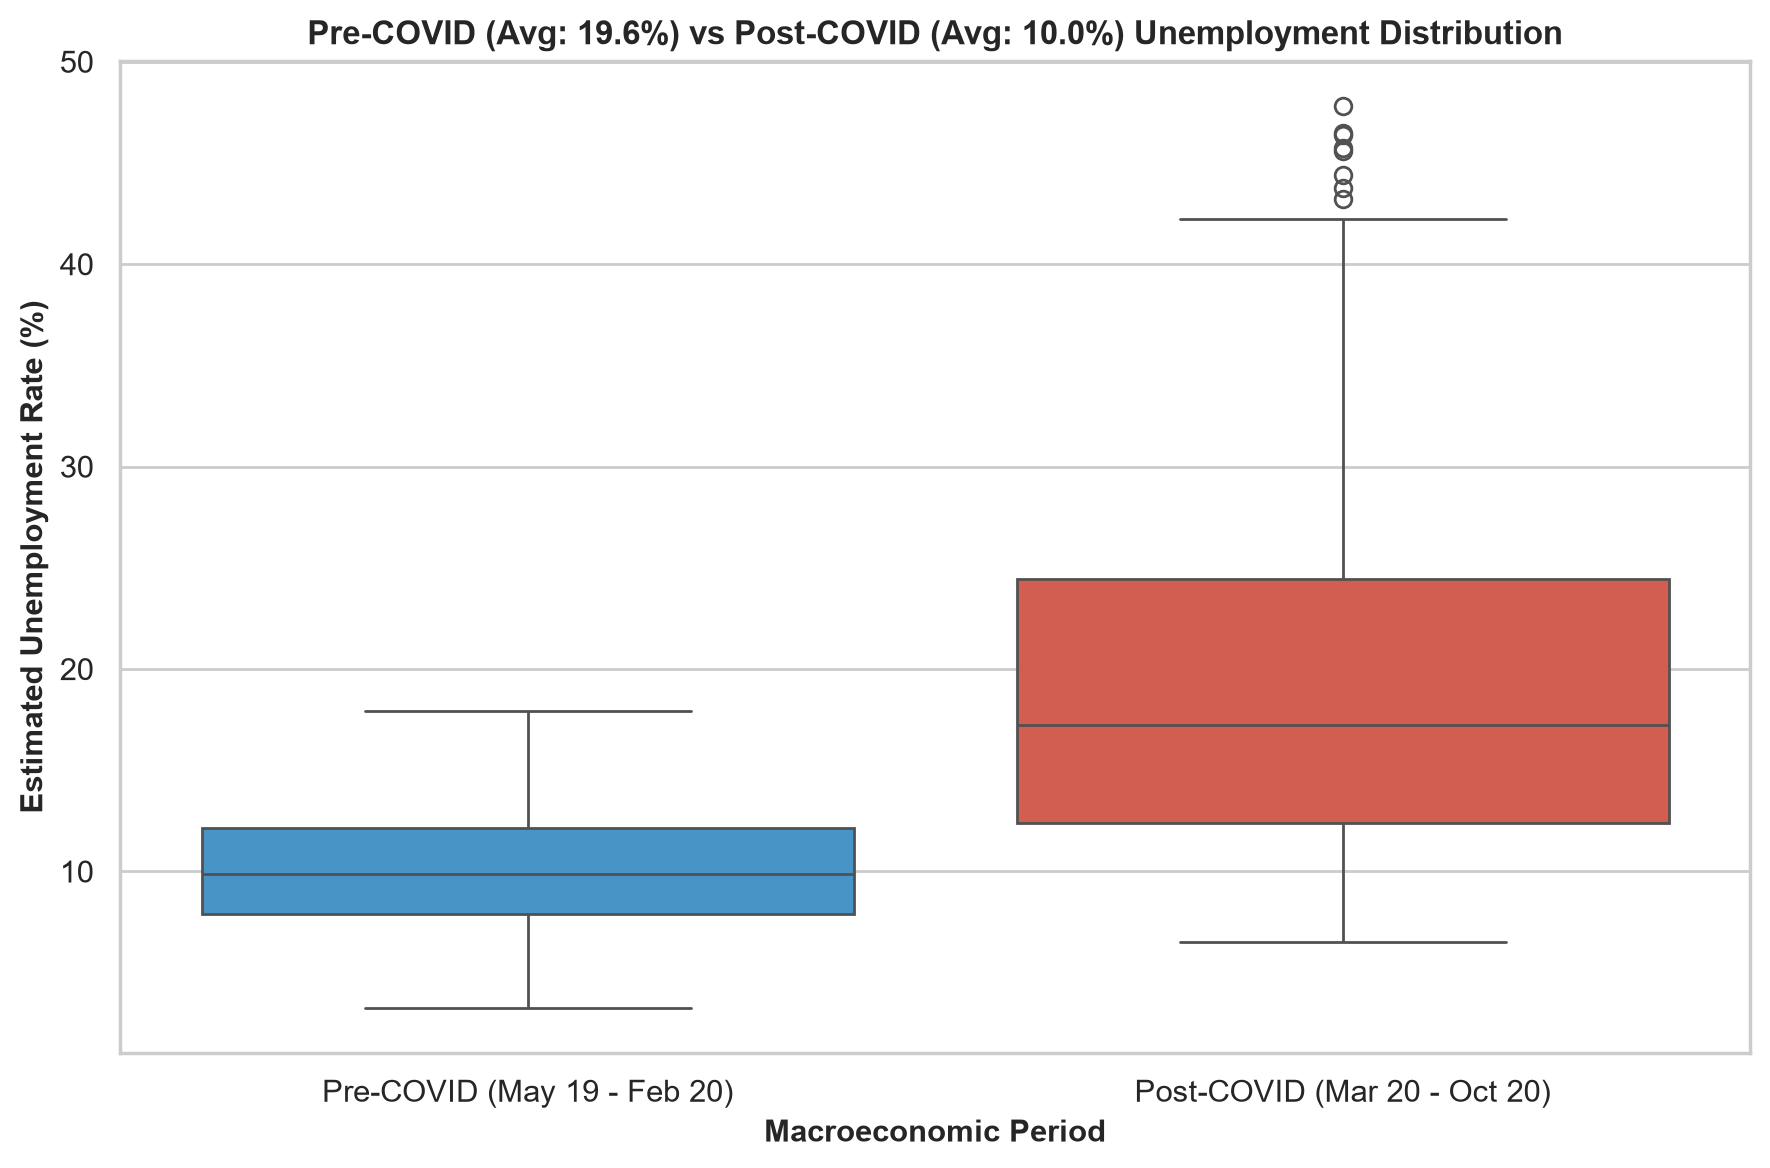

In [ ]:
lockdown_date = pd.to_datetime("2020-03-24")
df['Period'] = np.where(df['Date'] < lockdown_date, 'Pre-COVID (May 19 - Feb 20)', 'Post-COVID (Mar 20 - Oct 20)')

plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x='Period', y='Estimated Unemployment Rate (%)', palette=['#3498db', '#e74c3c'], hue='Period', legend=False)
means = df.groupby('Period')['Estimated Unemployment Rate (%)'].mean()
plt.title(f"Pre-COVID (Avg: {means.iloc[0]:.1f}%) vs Post-COVID (Avg: {means.iloc[1]:.1f}%) Unemployment Distribution", fontsize=12, fontweight='bold')
plt.ylabel("Estimated Unemployment Rate (%)", fontsize=11, fontweight='bold')
plt.xlabel("Macroeconomic Period", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

### 6. Key Findings & Policy Insights
1. **Unprecedented Spike:** Nationwide unemployment experienced an immediate spike in April-May 2020, rising more than 2.5x above baseline levels.
2. **Regional Resilience:** Southern and Western agrarian-industrial belts exhibited faster recovery trajectories compared to Eastern migrant-exporting economies.
3. **Labour Participation:** The Labour Participation Rate dropped sharply concurrently with unemployment surges, reflecting discouraged-worker effects during lockdowns.